<div style="border-left:6px solid #7c3aed;background:#f5f3ff;padding:20px 24px;border-radius:10px;color:#0f172a;">
  <div style="color:#7c3aed;font-size:12px;font-weight:700;letter-spacing:2px;">PYTORCH LAB · NONLINEAR CLASSIFICATION</div>
  <h1 style="margin:8px 0;color:#0f172a;">Nonlinear Data Practice</h1>
  <div style="color:#475569;">ReLU network · Adam · Probability maps</div>
</div>

### 🇬🇧 English

- **Goal:** binary seismic-event classification from two numeric features.
- **Architecture:** `2 → 10 → ReLU → 10 → ReLU → 1`; hidden activations enable a nonlinear classifier.
- **Roadmap:** inspect data → split and prepare float32 tensors → train with Adam → evaluate → visualize probabilities on a grid.
- This uses a different dataset from the linear notebook, so their scores do not isolate the effect of activations. Run cells in order; saved outputs are preserved.

### 🇹🇷 Türkçe

- **Amaç:** iki sayısal özellikten ikili deprem olayı sınıflandırması.
- **Mimari:** `2 → 10 → ReLU → 10 → ReLU → 1`; gizli aktivasyonlar doğrusal olmayan sınıflandırıcı sağlar.
- **Akış:** veriyi incele → ayır ve float32 tensörleri hazırla → Adam ile eğit → değerlendir → ızgarada olasılıkları görselleştir.
- Doğrusal notebook’tan farklı veri kullanılır; skorları sadece aktivasyon etkisini ölçmez. Hücreleri sırayla çalıştır; kayıtlı çıktılar korunur.

### 🗺️ Learning path / Öğrenme rotası

| 🔎 Explore / İncele | 🧱 Prepare / Hazırla | 🧠 Build / Kur | ⚙️ Train / Eğit | 📊 Visualize / Görselleştir |
| :--- | :--- | :--- | :--- | :--- |
| CSV & classes | 80/20 · float32 | Linear + ReLU | Adam · 500 epochs | Probability surface |

> 📌 **How to use / Nasıl kullanılır:** Run from top to bottom; each note explains the code below. / Yukarıdan aşağıya çalıştır; her not altındaki kodu açıklar.

---


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧰 SETUP · STEP 01</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Import libraries / Kütüphaneleri içe aktar</div>
</div>

### 🇬🇧 English

PyTorch handles tensors, models, and gradients; Pandas reads tables; NumPy prepares plotting grids; Matplotlib and Seaborn visualize samples and predictions.

### 🇹🇷 Türkçe

PyTorch tensörleri, modelleri ve gradyanları yönetir; Pandas tabloları okur; NumPy çizim ızgaralarını hazırlar; Matplotlib ve Seaborn örnekleri ve tahminleri görselleştirir.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🔎 DATA · STEP 02</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Load seismic data / Deprem aktivitesi verisini yükle</div>
</div>

### 🇬🇧 English

Read `../data/08-seismic_activity_svm.csv` into a DataFrame. The inputs are underground wave energy and vibration-axis variation; the target is `seismic_event_detected`. The filename does not mean the model is an SVM. The CSV must be available locally.

### 🇹🇷 Türkçe

`../data/08-seismic_activity_svm.csv` dosyasını DataFrame içine oku. Girdiler yeraltı dalga enerjisi ve titreşim ekseni değişimidir; hedef `seismic_event_detected` sütunudur. Dosya adı modelin SVM olduğunu göstermez. CSV yerel olarak bulunmalı.


In [2]:
df = pd.read_csv("../data/08-seismic_activity_svm.csv")

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🔎 DATA · STEP 03</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Preview the table / Tabloya göz at</div>
</div>

### 🇬🇧 English

`df.head()` shows the first five rows. Check feature names, numeric values, and the target encoding. Binary classification here expects target labels 0 and 1.

### 🇹🇷 Türkçe

`df.head()` ilk beş satırı gösterir. Özellik adlarını, sayısal değerleri ve hedef kodlamasını incele. Buradaki ikili sınıflandırma 0 ve 1 hedef etiketlerini bekler.


In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🔎 DATA · STEP 04</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Inspect class geometry / Sınıfların geometrisini incele</div>
</div>

### 🇬🇧 English

Plot the two features and color each point by the event label. Inspect whether a straight line can separate the classes or whether a more flexible boundary is needed. Visualization alone does not measure model performance.

### 🇹🇷 Türkçe

İki özelliği çiz ve noktaları olay etiketine göre renklendir. Sınıfların doğruyla ayrılıp ayrılamayacağını veya daha esnek sınır gerekip gerekmediğini incele. Görselleştirme tek başına model başarısını ölçmez.


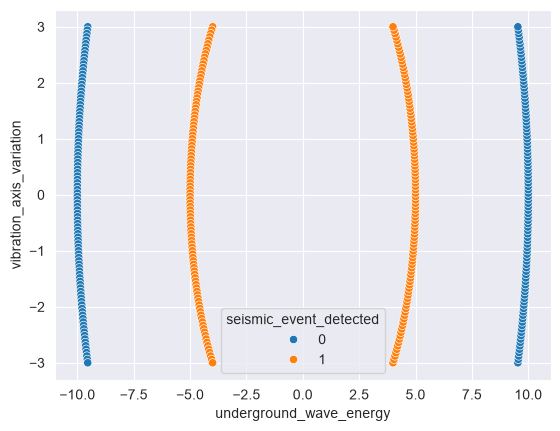

In [4]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 05</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Select feature table and target / Özellik tablosunu ve hedefi seç</div>
</div>

### 🇬🇧 English

`X` remains a two-column Pandas DataFrame; `y` remains a Series. This differs from the linear notebook, which converts to NumPy immediately. Feature order determines how the model interprets each input column.

### 🇹🇷 Türkçe

`X`, iki sütunlu Pandas DataFrame; `y`, Series olarak kalır. Doğrusal notebook burada doğrudan NumPy’a geçiyordu. Özellik sırası modelin her girdi sütununu nasıl yorumlayacağını belirler.


In [6]:
X = df[["underground_wave_energy", "vibration_axis_variation"]]
y = df["seismic_event_detected"]

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 06</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Import the split helper / Ayırma aracını içe aktar</div>
</div>

### 🇬🇧 English

`train_test_split` from Scikit-Learn separates aligned inputs and targets into training and test subsets.

### 🇹🇷 Türkçe

Scikit-Learn içindeki `train_test_split`, eşleşen girdi ve hedefleri eğitim ve test alt kümelerine ayırır.


In [5]:
from sklearn.model_selection import train_test_split

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 07</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Create a reproducible split / Tekrarlanabilir veri ayrımı oluştur</div>
</div>

### 🇬🇧 English

`test_size=0.2` reserves 20% for testing and 80% for training. The default behavior shuffles rows; `random_state=42` fixes this split. No `stratify` argument is supplied, so class proportions are not explicitly preserved. This seed does not control PyTorch model initialization.

### 🇹🇷 Türkçe

`test_size=0.2`, verinin %20’sini test ve %80’ini eğitim için ayırır. Varsayılan davranış satırları karıştırır; `random_state=42` bu ayrımı sabitler. `stratify` verilmediği için sınıf oranları özellikle korunmaz. Bu tohum PyTorch modelinin başlangıç parametrelerini kontrol etmez.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 08</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Inspect shapes before conversion / Dönüşümden önce şekilleri incele</div>
</div>

### 🇬🇧 English

Print the Pandas subset shapes. The saved output shows 320 training and 80 test samples, with two features each. Targets are still one-dimensional: `(320,)` and `(80,)`.

### 🇹🇷 Türkçe

Pandas alt kümelerinin şekillerini yazdır. Kayıtlı çıktı, iki özellikli 320 eğitim ve 80 test örneği gösteriyor. Hedefler hâlâ tek boyutlu: `(320,)` ve `(80,)`.


In [9]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(320, 2) (80, 2)
(320,) (80,)


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 09</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Create model-ready tensors / Modele uygun tensörleri oluştur</div>
</div>

### 🇬🇧 English

Extract NumPy arrays using `.values`, then create float32 tensors. Inputs have shape `(N, 2)`; `unsqueeze(1)` reshapes targets to `(N, 1)` so they match the output logits expected by `BCEWithLogitsLoss`. No feature scaling is applied here.

### 🇹🇷 Türkçe

`.values` ile NumPy dizilerini al ve float32 tensörleri oluştur. Girdiler `(N, 2)` şeklindedir; `unsqueeze(1)` hedefleri `(N, 1)` yaparak `BCEWithLogitsLoss` için çıktı logits şekliyle eşleştirir. Burada özellik ölçekleme uygulanmaz.


In [10]:
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧱 PREPARATION · STEP 10</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Verify shapes after conversion / Dönüşümden sonra şekilleri doğrula</div>
</div>

### 🇬🇧 English

Check that feature shapes stay `(320, 2)` and `(80, 2)`, while targets become `(320, 1)` and `(80, 1)`. The added axis changes layout without adding samples or features.

### 🇹🇷 Türkçe

Özellik şekillerinin `(320, 2)` ve `(80, 2)` kaldığını, hedeflerin `(320, 1)` ve `(80, 1)` olduğunu kontrol et. Eklenen eksen örnek veya özellik eklemeden düzeni değiştirir.


In [11]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([80, 2])
torch.Size([320, 1]) torch.Size([80, 1])


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧠 MODEL · STEP 11</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Build a nonlinear network / Doğrusal olmayan ağı kur</div>
</div>

### 🇬🇧 English

Define the sequence `2 → 10 → ReLU → 10 → ReLU → 1`. ReLU computes `max(0, x)` between hidden layers, enabling a nonlinear relationship between inputs and the final logit. Keep the final layer without sigmoid because the loss accepts logits. Unlike the linear notebook, these activations prevent the network from collapsing into one affine layer.

### 🇹🇷 Türkçe

`2 → 10 → ReLU → 10 → ReLU → 1` dizisini tanımla. ReLU gizli katmanlar arasında `max(0, x)` hesaplayarak girdilerle son logit arasında doğrusal olmayan ilişki kurulmasını sağlar. Kayıp logits aldığı için son katmana sigmoid eklenmez. Doğrusal notebook’tan farklı olarak bu aktivasyonlar ağın tek afin katmana indirgenmesini önler.


In [12]:
from torch import nn

class NonLinearModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))



<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">🧠 MODEL · STEP 12</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Initialize the network / Ağı başlat</div>
</div>

### 🇬🇧 English

Instantiate `NonLinearModel` with random parameters. The later `manual_seed(42)` call happens after initialization, so it cannot fix these starting weights retrospectively. Reproducible initialization would require setting the seed before this cell.

### 🇹🇷 Türkçe

`NonLinearModel` nesnesini rastgele parametrelerle oluştur. Sonraki `manual_seed(42)` çağrısı başlangıçtan sonra gelir; bu başlangıç ağırlıklarını geriye dönük sabitleyemez. Tekrarlanabilir başlangıç için tohum bu hücreden önce ayarlanmalı.


In [13]:
model = NonLinearModel()

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">⚙️ TRAINING · STEP 13</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Configure binary loss and Adam / İkili kaybı ve Adam’ı ayarla</div>
</div>

### 🇬🇧 English

`BCEWithLogitsLoss` compares raw logits with float targets encoded as 0/1. Adam uses moving averages of gradients and squared gradients to adapt parameter updates, with base learning rate `0.001`. Sigmoid is used separately for interpretation and accuracy.

### 🇹🇷 Türkçe

`BCEWithLogitsLoss`, ham logits ile 0/1 olarak kodlanmış float hedefleri karşılaştırır. Adam, güncellemeleri uyarlamak için gradyanların ve gradyan karelerinin hareketli ortalamalarını kullanır; temel öğrenme oranı `0.001` olur. Sigmoid yorumlama ve doğruluk için ayrıca kullanılır.


In [14]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">⚙️ TRAINING · STEP 14</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Define binary accuracy / İkili sınıflandırma doğruluğunu tanımla</div>
</div>

### 🇬🇧 English

`torch.eq` compares predicted and true labels element by element. Sum the matches, convert the scalar with `.item()`, divide by the sample count, and multiply by 100. The result is a percentage. Both tensors must have matching `(N, 1)` shapes; mismatched shapes could broadcast and produce an incorrect count.

### 🇹🇷 Türkçe

`torch.eq`, tahmini ve gerçek etiketleri eleman bazında karşılaştırır. Eşleşmeleri topla, `.item()` ile skaler değeri al, örnek sayısına böl ve 100 ile çarp. Sonuç yüzdedir. İki tensörün şekli de `(N, 1)` olmalı; farklı şekiller broadcasting nedeniyle yanlış sayım üretebilir.


In [15]:
def calculate_accuracy(y_pred, y_test):
    correct = torch.eq(y_pred, y_test).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">⚙️ TRAINING · STEP 15</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Train for 500 epochs / 500 epoch eğit</div>
</div>

### 🇬🇧 English

Each epoch uses the whole training set for one update.

1. Predict logits, then apply sigmoid and rounding to obtain labels for accuracy. Exactly 0.5 rounds to 0.
2. Compute loss from the raw logits and accuracy from labels.
3. `zero_grad()` clears old gradients, `backward()` computes new gradients, and `step()` updates parameters.
4. Use `eval()` and `inference_mode()` to evaluate test loss and accuracy without updates.
5. Print metrics every 50 epochs; train metrics precede the update and test metrics follow it.

> 🔍 **Code detail:** this loop does not call `model.train()` at the start of each epoch. A fresh model starts in training mode but stays in evaluation mode after the first test pass. Linear and ReLU layers behave the same in both modes, so this architecture still trains; Dropout or BatchNorm would require restoring training mode. The seed is also set after model initialization.

The saved output reports 100% test accuracy at epoch 450 on this split; this is an existing run, not a new verification or a guarantee for other data. Use a validation split for tuning rather than repeatedly selecting choices from test results.

### 🇹🇷 Türkçe

Her epoch, tüm eğitim kümesiyle tek güncelleme yapar.

1. Logits üret; doğruluk etiketleri için sigmoid ve yuvarlama uygula. Tam 0.5 değeri 0’a yuvarlanır.
2. Kaybı ham logits, doğruluğu etiketler üzerinden hesapla.
3. `zero_grad()` eski gradyanları temizler, `backward()` yenilerini hesaplar, `step()` parametreleri günceller.
4. Güncelleme yapmadan test kaybı ve doğruluğu için `eval()` ve `inference_mode()` kullan.
5. Her 50 epoch’ta metrikleri yazdır; eğitim metrikleri güncellemeden önce, test metrikleri sonra gelir.

> 🔍 **Kod ayrıntısı:** bu döngü her epoch başında `model.train()` çağırmıyor. Yeni model eğitim modunda başlar ancak ilk testten sonra değerlendirme modunda kalır. Linear ve ReLU iki modda aynı davranır; bu mimari yine eğitilir. Dropout veya BatchNorm kullanılırsa eğitim moduna dönmek gerekir. Tohum da model oluşturulduktan sonra ayarlanır.

Kayıtlı çıktı bu ayrımda epoch 450 için %100 test doğruluğu bildiriyor; bu mevcut çalıştırmanın sonucudur, yeni doğrulama veya başka veriler için garanti değildir. Ayarları tekrar tekrar test sonucundan seçmek yerine doğrulama kümesi kullan.


In [17]:
torch.manual_seed(42)
epochs = 500

for epoch in range(epochs):

    y_logits = model(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_test=y_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():

      test_logits = model(X_test)
      test_pred = torch.round(torch.sigmoid(test_logits))

      test_loss = loss_fn(test_logits, y_test)
      test_acc = calculate_accuracy(y_test=y_test, y_pred=test_pred)

    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69922, Accuracy: 48.75% | Test Loss: 0.68826, Test Accuracy: 55.00%
Epoch: 50 | Loss: 0.64931, Accuracy: 48.75% | Test Loss: 0.63830, Test Accuracy: 55.00%
Epoch: 100 | Loss: 0.60497, Accuracy: 56.56% | Test Loss: 0.59587, Test Accuracy: 57.50%
Epoch: 150 | Loss: 0.54352, Accuracy: 65.00% | Test Loss: 0.53739, Test Accuracy: 65.00%
Epoch: 200 | Loss: 0.45562, Accuracy: 74.38% | Test Loss: 0.44870, Test Accuracy: 80.00%
Epoch: 250 | Loss: 0.34628, Accuracy: 92.50% | Test Loss: 0.33144, Test Accuracy: 96.25%
Epoch: 300 | Loss: 0.24564, Accuracy: 100.00% | Test Loss: 0.23284, Test Accuracy: 100.00%
Epoch: 350 | Loss: 0.17137, Accuracy: 100.00% | Test Loss: 0.16267, Test Accuracy: 100.00%
Epoch: 400 | Loss: 0.12179, Accuracy: 100.00% | Test Loss: 0.11500, Test Accuracy: 100.00%
Epoch: 450 | Loss: 0.08874, Accuracy: 100.00% | Test Loss: 0.08314, Test Accuracy: 100.00%


<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">📊 VISUALIZATION · STEP 16</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Visualize the probability surface / Olasılık yüzeyini görselleştir</div>
</div>

### 🇬🇧 English

Expand both feature ranges by one unit, build a `300 × 300` meshgrid, and flatten it into 90,000 two-feature points. Run the model without gradients, convert logits to probabilities with sigmoid, and reshape them back to the grid. `contourf` colors the probability surface; the scatter overlay shows true labels.

Although the code comment mentions a 0.5 threshold, no explicit threshold or `contour(..., levels=[0.5])` is applied here. This is a probability map, not an explicitly drawn 0.5 decision line. Conversion to NumPy and the grid inputs assume CPU execution.

### 🇹🇷 Türkçe

İki özellik aralığını birer birim genişlet, `300 × 300` meshgrid kur ve 90.000 iki özellikli noktaya düzleştir. Modeli gradyan takibi olmadan çalıştır, sigmoid ile logits değerlerini olasılığa çevir ve ızgara şekline döndür. `contourf` olasılık yüzeyini renklendirir; üzerine eklenen noktalar gerçek etiketleri gösterir.

Kod yorumunda 0.5 eşiği geçse de burada açık eşikleme veya `contour(..., levels=[0.5])` uygulanmaz. Bu bir olasılık haritasıdır; açıkça çizilmiş 0.5 karar doğrusu değildir. NumPy dönüşümü ve ızgara girdileri CPU üzerinde çalışmayı varsayar.


In [18]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)

    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

<div style="border-left:4px solid #7c3aed;background:#f5f3ff;padding:12px 16px;border-radius:8px;color:#0f172a;">
  <div style="font-size:11px;font-weight:700;color:#7c3aed;letter-spacing:1px;">📊 VISUALIZATION · STEP 17</div>
  <div style="font-size:18px;font-weight:600;margin-top:5px;">Compare probability maps / Olasılık haritalarını karşılaştır</div>
</div>

### 🇬🇧 English

Draw two panels with the same trained model, using training and test samples respectively. Each call creates a grid from that subset, so plot ranges can differ. The helper sets the title to `Non-linear Decision Boundary`, overwriting the earlier `Train`/`Test` titles; the left/right panels still use train/test data.

### 🇹🇷 Türkçe

Aynı eğitilmiş modelle iki panel çiz; sırayla eğitim ve test örneklerini kullan. Her çağrı kendi alt kümesinden ızgara kurar, dolayısıyla çizim aralıkları farklı olabilir. Yardımcı fonksiyon başlığı `Non-linear Decision Boundary` yaparak önceki `Train`/`Test` başlıklarını değiştirir; sol/sağ paneller yine eğitim/test verisini kullanır.


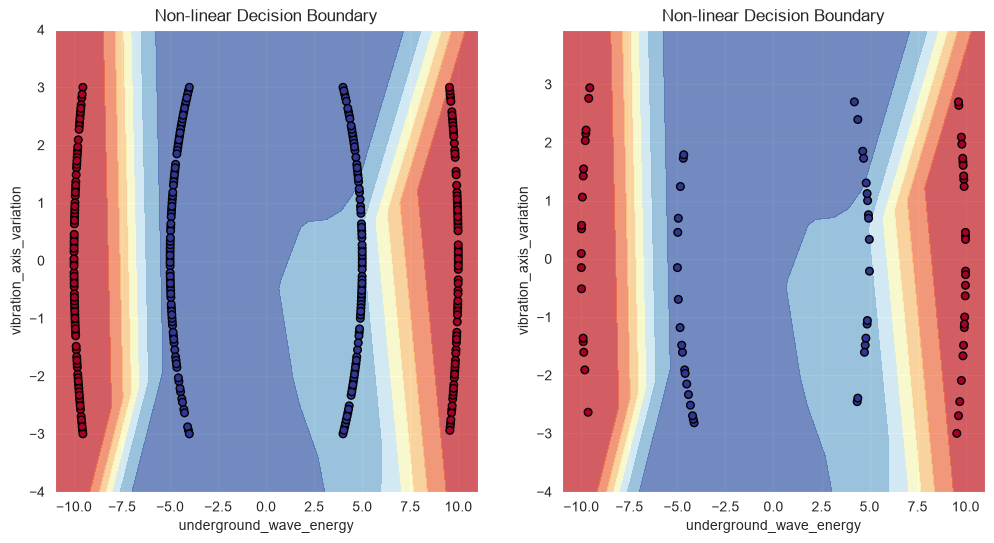

In [20]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()